In [96]:
import argparse
import os

import pandas as pd
import pickle
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import torch
from torch import optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import sys

In [97]:
# top r svd
def top_r_svd(A, r):
    V, S, Vt = torch.linalg.svd(A, full_matrices=True)

    Vr = V[:, :r]  
    Sr = S[:r]   
    Vtr = Vt[:r, :]
    return Vr, Sr, Vtr

# norm by dividing the max singular value
def svd_norm(A):
    U, S, V = torch.svd(A)

    S_normalized = S / S.max()
    scale = S.max()

    A_normalized = U @ torch.diag(S_normalized) @ V.t()

    return A_normalized, scale

# norm by UV
def uv_norm(A):
    U, S, V = torch.svd(A)

    A_normalized = U @ V.t()

    return A_normalized

# reverse norm by multipying the max singular value
def svd_norm_reverse(A, scale):
    U, S, V = torch.svd(A)

    S_reverse = S * scale

    A_normalized = U @ torch.diag(S_reverse) @ V.t()

    return A_normalized

In [98]:
def load_data_all(dataset, s):
    print(dataset)
    preprocess_file = './data/'+dataset+'.pkl'
    full_M_file = './data/'+dataset+'/matrix.pt'
    if dataset == 'random':
        mat1 = torch.randn(100,1)
        mat2 = torch.randn(1, 5)
        matrix = mat1 @ mat2
        return matrix

    elif dataset == 'ml-1m':
        # read table
        ratings_title = ['UserID','MovieID', 'ratings', 'timestamps']
        ratings = pd.read_table('~/dataset/ml/'+'ml-1m/ratings.dat', sep='::', header=None, names=ratings_title, engine = 'python')
        ratings = ratings.filter(regex='UserID|MovieID|ratings')

        # sample
        unique_ids = ratings['MovieID'].unique()
        selected_ids = np.random.choice(unique_ids, size=s, replace=False)
        selected_data = ratings[ratings['MovieID'].isin(selected_ids)]

        #selected_data = torch.tensor(selected_data.values)
        matrix_df = selected_data.pivot_table(index='UserID', columns='MovieID', values='ratings', aggfunc='first')
        matrix_df = matrix_df.fillna(0)
        matrix = torch.tensor(matrix_df.values)

        return matrix
    
    elif dataset == 'netflix':
        df = pd.read_csv(
            "./data/netflix/data.csv",
            names=["movie_id", "user_id", "rating", "date"],
            parse_dates=["date"],
            encoding="ISO-8859-1",
            engine="python",
        )
        data = df[["movie_id", "user_id", "rating"]]
        # sample
        unique_ids = data['movie_id'].unique()
        selected_ids = np.random.choice(unique_ids, size=s, replace=False)
        selected_data = data[data['movie_id'].isin(selected_ids)]

        #selected_data = torch.tensor(selected_data.values)
        matrix_df = selected_data.pivot_table(index='user_id', columns='movie_id', values='rating', aggfunc='first')
        matrix_df = matrix_df.fillna(0)
        matrix = torch.tensor(matrix_df.values)

        return matrix
    
    elif dataset == 'gene':
        M = load_data_gene()


In [99]:
dataset = 'ml-1m'
M = load_data_all(dataset, s=300)

print(f"original user: {M.shape[0]} item: {M.shape[1]}")
M = M.float()

ml-1m
original user: 5915 item: 300


In [100]:
"""
d1 = 5000
r = 5
d2 = 100

mat1 = torch.randn(d1, 30)
mat2 = torch.randn(30, d2)
M = mat1 @ mat2
"""
r = 3
p = 0.5 # observe rate
noise = 0.0
#M = M[torch.count_nonzero(M, dim=1)>r]
print(f"used user: {M.shape[0]} item: {M.shape[1]}")
mask = torch.bernoulli(torch.full((M.shape[0],), 1-p)).bool()
M

used user: 5915 item: 300


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

norm of M: 1105.5555419921875


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:53<00:00, 18.86it/s, In epoch 999, loss: 86399.688)] 


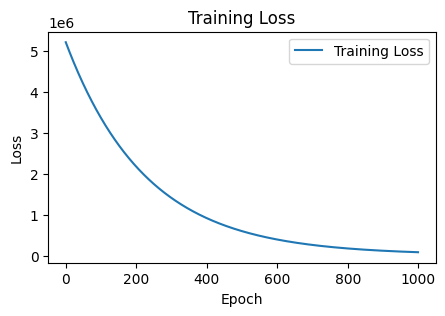

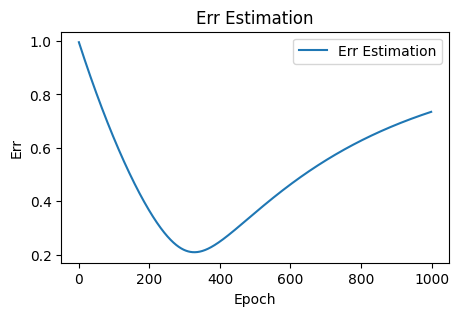

In [101]:
"""
Train for X
"""
device = 'cuda:7'
# observed M & norm
M = M.to(device)
observed_M = deepcopy(M)
observed_M[mask] = 0 # mask user
#observed_M = M
#observed_M_norm, scale_M = svd_norm(observed_M) # svd norm
MTM = observed_M.t() @ observed_M
norm = torch.norm(MTM)
#MTM /= norm

scale_diag = (p - 1) / (p ** 2) * torch.diag(MTM).diag() # objective matrix
A = scale_diag + 1 / (p ** 2) * MTM

print(f"norm of M: {torch.norm(M)}")

# parameters setting
d1, d2 = observed_M.shape
X = torch.randn(d2, d2, requires_grad=True, device=device)
#X = torch.tensor(MTM, requires_grad=True)

epochs = 1000
alpha = 0.1

loop = tqdm(range(epochs))
#eta = 1 / np.sqrt(epochs)
eta = 100
optimizer = optim.SGD([X], lr=eta)

# opt
train_losses = []
err_estimates = []
#writer = SummaryWriter('runs/'+dataset)
for i in loop:
    loss = ((X - A)**2).mean() # mse loss
    with torch.no_grad():
        U, D, Vt = torch.linalg.svd(X.detach(), full_matrices=False)
    loss.backward()

    noise_matrix = torch.normal(mean=0, std=noise, size=(d2, d2), device=device)

    X.grad = X.grad + alpha * U @ Vt + noise_matrix # alg
    """
    with torch.no_grad():
        X.data += -eta*X.grad
    """
    optimizer.step()
    X.grad.zero_()
    #print(loss.item())
    #writer.add_scalar('Loss', loss.item(), i)
    train_losses.append(loss.item())
    err = X - M.T @ M
    err_estimates.append((torch.norm(err)/torch.norm(M.T @ M)).item())
    loop.set_postfix_str('In epoch {}, loss: {:.3f})'.format(i, loss.item()))

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(err_estimates, label='Err Estimation')
plt.xlabel('Epoch')
plt.ylabel('Err')
plt.title('Err Estimation')
plt.legend()



In [102]:
"""
normalization for result
"""
#X, _ = svd_norm(X)
u, d, vt = torch.linalg.svd(X)
#X = vt.t() @ vt

err = X - M.T @ M

#print(f"x - mtm: {X - M.T @ M}")

print(torch.norm(err), torch.norm(M.T @ M))
print(torch.norm(X))
#print(f"norm of X: {torch.norm(X)}")
#print(f"norm of M: {torch.norm(M.T @ M)}")


tensor(263827.1562, device='cuda:7', grad_fn=<LinalgVectorNormBackward0>) tensor(359030.3125, device='cuda:7')
tensor(604106.9375, device='cuda:7', grad_fn=<LinalgVectorNormBackward0>)


In [103]:
import torch.nn as nn

def train_opt(A, B, C, max_value, min_value):
    r = A.shape[0]
    A = A.detach()
    W = torch.randn(r, r, dtype=torch.float32, requires_grad=False)
    linear_layer = nn.Linear(r, r).to(device)
    x = torch.nn.Parameter(torch.randn((1,r), dtype=torch.float32, device=device))
    #x = torch.randn((1, r), dtype=torch.float32, device=device, requires_grad=True)
    #optimizer = optim.Adam(list(linear_layer.parameters())+ [x], lr=0.01, weight_decay=0.1)
    optimizer = optim.Adam([x], lr=0.01, weight_decay=10)
    loss_fn = nn.MSELoss()

    epochs = 50
    for e in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(x @ A, B)
        loss.backward()
        optimizer.step()
        print(x.grad)
        print(loss.item())
    

    return x.detach()

def to_numpy(input_data):
    # 检查输入数据是否为 PyTorch 张量
    if isinstance(input_data, torch.Tensor):
        # 确保张量在 CPU 上，然后转换为 NumPy 数组
        return input_data.detach().cpu().numpy()
    # 检查输入数据是否为 NumPy 数组
    elif isinstance(input_data, np.ndarray):
        # 如果已经是 NumPy 数组，直接返回
        return input_data
    else:
        # 如果输入既不是张量也不是 NumPy 数组，则抛出异常
        raise TypeError("输入必须是 PyTorch Tensor 或 NumPy ndarray.")

from scipy.optimize import minimize

def constrain_opt(A, B, C, r, max_value, min_value):
    A = to_numpy(A)
    B = to_numpy(B)
    C = to_numpy(C)
    print(A.shape)
    print(B.shape)
    print(C.shape)
    d = np.full((C.shape[0],), max_value) 
    #d = max_value
    #print(d)

    # 目标函数：最小化 ||Ax - B||^2
    lambda_reg = 10
    I = np.eye(A.shape[1]) * lambda_reg
    def objective(x):
        #return np.mean((A @ x - B) ** 2)
        return np.mean(((A.T @ A + I) @ x - A.T @ B) ** 2)

    # 约束条件
    constraints = [
        {'type': 'ineq', 'fun': lambda x: d - C @ x},  # Cx < d
        {'type': 'ineq', 'fun': lambda x: C @ x}       # Cx > 0
    ]

    # 初始猜测
    x0 = np.zeros(r)
    #print(x0.shape)
    #print(A @ x0)

    # 调用 minimize 函数进行优化
    result = minimize(objective, x0, constraints=constraints)
    #result = minimize(objective, x0)
    #print(objective(result.x))
    return torch.tensor(result.x)

In the case r=1, use every column to recover M independently. If M can be retrieved, the result should be similar in every column.

The key is the gap between estimated r and real r

In [113]:
miss_users = torch.tensor(range(M.shape[0]))[mask]

#X = M.t() @ M
#mat = torch.randn(d2,d2, device=device)
#_, S, item_vector = top_r_svd(mat, r)
#_, S, item_vector = top_r_svd(M.t() @ M, r)
_, S, item_vector = top_r_svd(X, r)
#item_vector, S = top_r_eigen(X, r)
#item_vector = item_vector * torch.sqrt(S)
V, S, Vt = torch.linalg.svd(A, full_matrices=True)
"""
Vr = V[:, :r]  
Sr = S[:r]   
Vtr = Vt[:r, :]
"""
predict_matrix = []
miss_item_u = []
error_list = []
test_num = 0
for i in tqdm(range(miss_users.shape[0])):
#for i in range(5):
    """
    M_u: 1*d2
    item_vector: r*d2
    useR_vector: 1*r
    """
    
    M_u = M[miss_users][i]
    non_zero_indices = M_u.nonzero(as_tuple=True)[0]
    #print(non_zero_indices)
    #print(f"M_u: {M_u[non_zero_indices]}")
    # train mask
    M_u = M_u.unsqueeze(0)
    n = non_zero_indices.shape[0]
    
    #num_to_select = max(r, int(n * p))
    #num_to_select = int(n * p)
    num_to_select = n-1
    item_vector = Vt[:n, :]
    # 选取num_to_select个元素的下标
    selected_indices = non_zero_indices[:num_to_select]
    # 获取未被选出的下标
    non_selected_indices = non_zero_indices[num_to_select:]
    test_num += num_to_select
    #print(f"test_num: {test_num}")

    train_A = item_vector[:, selected_indices]
    train_B = M_u[:, selected_indices]
    #train_A = item_vector[:, non_zero_indices]
    #train_B = M_u[:, non_zero_indices]
    test_A = item_vector[:, non_selected_indices]
    test_B = M_u[:, non_selected_indices]

    # 正则化参数
    lambda_reg = 0.01
    I = torch.eye(train_A.shape[0], device=device) * lambda_reg

    # 岭回归求解
    u = torch.linalg.lstsq(train_A @ train_A.t() + I, train_A @ train_B.t()).solution.t()

    #u = torch.linalg.lstsq(train_A.t(), train_B.t()).solution.t()
    #u = train_opt(A=train_A, B=train_B, C=None, max_value=5, min_value=0)
    #u = constrain_opt(A=train_A.t(), B=train_B.t(), C=test_A.t(), r=r, max_value=5, min_value=0).float().to(device)
    #print(u.shape)
    #print(f"train_A: {train_A}")
    #print(f"train_A: {train_B}")
    #print(f"train_A: {test_A}")
    #print(f"train_A: {test_B}")
    #print(f"u: {u}")
    """
    print(u @ train_A)
    print(f"train loss: {u @ train_A - train_B}")
    print(f"predict: {u @ test_A}")
    print(f"label: {M_u[:,non_selected_indices]}")
    print(f"ALL predict: {u @ item_vector[:, non_zero_indices]}")
    print(f"ALL label: {M_u[:, non_zero_indices]}")
    """
    error_list.append(torch.sum((u @ test_A - test_B)**2).item())
    #error_list.append(torch.sum((u @ item_vector[:, non_zero_indices] - M_u[:, non_zero_indices])**2).item())
    #print()
    
    

print(np.sqrt(np.sum(error_list)/test_num))




0.7627727988034316
